Proyecto2
Extraer la información de las diferentes fuentes
Graficar

In [1]:
%pip install fpdf 
import yfinance
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.application import MIMEApplication
import matplotlib.pyplot as plt
from fpdf import FPDF


Note: you may need to restart the kernel to use updated packages.


In [2]:
tiker = input("Escriba el codigo de la acción: ")

data = yfinance.download([tiker] , period= "1mo")

cierre = round(data.Close[tiker], 2)

[*********************100%***********************]  1 of 1 completed


Date
2026-08-31    316.85
2026-09-01    325.13
2026-09-02    324.96
2026-09-03    328.21
2026-09-04    319.97
2026-09-08    316.22
2026-09-09    315.34
2026-09-10    326.57
2026-09-11    332.27
2026-09-14    333.08
2026-09-15    331.34
2026-09-16    332.41
2026-09-17    337.00
2026-09-18    336.13
2026-09-21    338.98
2026-09-22    339.75
2026-09-23    337.02
2026-09-24    335.92
2026-09-25    341.07
2026-09-28    338.40
Name: AAPL, dtype: float64


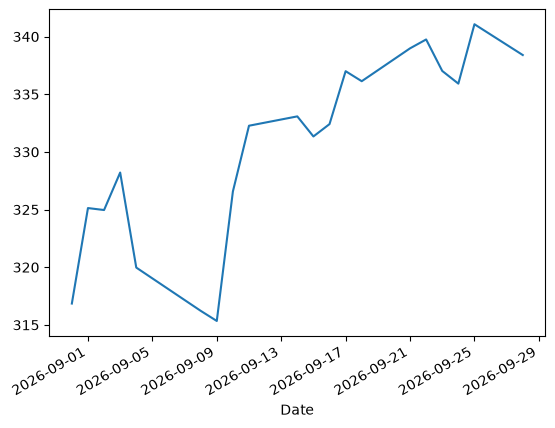

In [3]:
print(cierre)
grafica = cierre.plot()

In [4]:
## Codigo para generar la tabla de estadísticas descriptivas (Describe)
descriptiva = round(cierre.describe(), 2)
print (descriptiva)

count     20.00
mean     330.33
std        8.28
min      315.34
25%      325.09
50%      332.34
75%      337.00
max      341.07
Name: AAPL, dtype: float64


Hacer los análisis solicitados
Cotización máxima
Cotización mínica
Cotización promedio

In [5]:
max = round(cierre.max(),2)
min = round(cierre.min(),2)
promd = round(cierre.mean(),2)
print (max)
print(min)
print(promd)

341.07
315.34
330.33


In [6]:
## Codigo para crear el PDF con información
fpdf = FPDF()
fpdf.add_page()
fpdf.set_font("Arial", size=12)
fpdf.cell(200,10, txt = "Reporte de la acción: " + tiker, ln=1, align='C')
fpdf.cell(200,10, txt = "Precio máximo: " + str(max), ln=2, align='L')
fpdf.cell(200,10, txt = "Precio mínimo: " + str(min), ln=3, align='L')
fpdf.cell(200,10, txt = "Precio promedio: " + str(promd), ln=4, align='L')
fpdf.cell(200,10, txt = "Tabla de precios de cierre: " + tiker, ln=5, align='L')
fpdf.cell(200,10, txt = "Estadistica descriptiva: ", ln=6, align='L')

##Codigo para generar la tabla de estadísticas descriptivas y agregarla al PDF
fpdf.cell(50, 8, "Estadística", border=1, ln=0, align='C')
fpdf.cell(50, 8, "Valor", border=1, ln=1, align='C')
for index, value in descriptiva.items():
    fpdf.cell(50, 9 , str(index) , border=1, ln=0, align='L')
    fpdf.cell(50, 9, str(value) , border=1, ln=1, align='L')


##Codigo para generar la tabla de precios de cierre y agregarla al PDF
tabla = cierre.reset_index()
tabla.columns = ["Date", "Precio de cierre"]
tabla["Date"] = tabla["Date"].dt.strftime("%d/%m/%Y")

## Codigo para generar encabezados de tabla
fpdf.add_page()
fpdf.cell(50, 8, "Fecha", border=1, ln=0, align='C')
fpdf.cell(50, 8, "Precio de cierre", border=1, ln=1, align='C')

##Codigo para generar filas de datos de tabla
for _, fila in tabla.iterrows():
    fpdf.cell(50, 8 , str(fila["Date"]) , border=1, ln=0, align='L')
    fpdf.cell(50, 8, str(fila["Precio de cierre"]) , border=1, ln=1, align='L')
fpdf.ln()

## Codigo para generar la gráfica y guardarla como imagen
plt.Figure(figsize=(10, 6))
cierre.plot()
plt.title("Gráfica de precios de cierre: " + tiker)
plt.xlabel("Date")
plt.ylabel("Precio de cierre")
plt.savefig("grafica.png")
plt.close()

##Insertar la imagen en el PDF
fpdf.add_page()
fpdf.image("grafica.png", x=10, y=30, w=180)

##Generar el PDF
fpdf.output("reporte.pdf")

''

In [8]:
##Crear el correo electrónico para enviar el reporte
from dotenv import load_dotenv
import os

load_dotenv()

remitente = os.getenv("EMAIL_REMITENTE")
contraseña = os.getenv("EMAIL_CONTRASEÑA")
destinatario = os.getenv("EMAIL_DESTINATARIO")

## CRear el mensaje de correo electrónico
mensaje = MIMEMultipart()
mensaje["From"] = remitente
mensaje["To"] = destinatario
mensaje["Subject"] = "Reporte de la acción: " + tiker

## Agregar el cuerpo del mensaje (Que dice el correo)
cuerpo = "Adjunto encontrará el reporte generado de manera automática de la acción: " + tiker
mensaje.attach(MIMEText(cuerpo, "plain"))

## Adjuntar el archivo PDF al mensaje
with open("reporte.pdf", "rb") as archivo:
    adjunto = MIMEApplication(archivo.read(), _subtype="pdf")
    adjunto.add_header("Content-Disposition", "attachment", filename="reporte.pdf")
    mensaje.attach(adjunto)

### Enviar el correo electrónico
with smtplib.SMTP("smtp.gmail.com", 587) as servidor:
    servidor.starttls()
    servidor.login(remitente, contraseña)
    servidor.send_message(mensaje)



